# Data Visualization with Matplotlib and Seaborn
## Complete Guide to Plotting in Python

## 1. Introduction to Matplotlib and Seaborn

### What is Matplotlib?
- **Matplotlib** is the foundational plotting library in Python
- It provides a MATLAB-like interface for creating static, animated, and interactive visualizations
- It's highly customizable and flexible
- It serves as the base for many other visualization libraries

**Key Features:**
- Full control over every aspect of a figure
- Supports many output formats (PNG, PDF, SVG, etc.)
- Works with NumPy arrays and pandas DataFrames
- Object-oriented and pyplot interfaces

### What is Seaborn?
- **Seaborn** is built on top of Matplotlib
- It provides a high-level interface for statistical visualizations
- It comes with beautiful default themes and color palettes
- It's specifically designed for exploring and understanding data

**Key Features:**
- Statistical visualizations (distributions, regressions, heatmaps)
- Automatic handling of categorical variables
- Built-in datasets for practice
- Integration with pandas DataFrames
- Superior default aesthetics

### Matplotlib vs Seaborn

| Aspect | Matplotlib | Seaborn |
|--------|-----------|---------|
| **Complexity** | Low-level, more control | High-level, less control |
| **Default Aesthetics** | Basic, functional | Beautiful, publication-ready |
| **Statistical Plots** | Limited | Built-in (distributions, regression) |
| **Categorical Data** | Manual handling | Automatic handling |
| **Learning Curve** | Steeper | Easier |
| **Customization** | Very flexible | Limited but sufficient |
| **Use Case** | Complete control over figures | Quick statistical visualization |

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Display settings
%matplotlib inline

# Check versions
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

# Set seaborn style (optional but recommended)
sns.set_theme(style="whitegrid")

# IMPORTANT:
# plt - Matplotlib's pyplot module
# sns - Seaborn module
# %matplotlib inline - Shows plots in Jupyter notebooks

Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## 2. Understanding the Plotting Ecosystem

### Anatomy of a Figure

Every plot has these components:

```
┌─────────────────────────────────────────────────────────────┐
│ FIGURE (The whole canvas)                                   │
│  ┌─────────────────────────────────────────────────────────┐│
│  │ AXES (The plotting area)                                ││
│  │  ┌─────────────────────────────────────────────────────┐││
│  │  │ TITLE                                               │││
│  │  ├─────────────────────────────────────────────────────┤││
│  │  │                   ┌──────────────┐                 │││
│  │  │  Y-AXIS LABEL     │   PLOT       │   LEGEND       │││
│  │  │                   │              │                │││
│  │  │                   └──────────────┘                 │││
│  │  │          X-AXIS LABEL                              │││
│  │  └─────────────────────────────────────────────────────┘│
│  └─────────────────────────────────────────────────────────┘│
└─────────────────────────────────────────────────────────────┘
```

### Two Ways to Use Matplotlib

**1. pyplot (state-based) - Quick and easy**
- Best for simple plots
- Less control, but faster to write

**2. Object-Oriented (explicit) - More control**
- Best for complex plots
- Full control over all elements
- Reusable figure and axes objects

In [2]:
# Creating sample data for all examples
np.random.seed(42)

# Time series data
x = np.linspace(0, 10, 50)
y1 = np.sin(x) + np.random.normal(0, 0.1, 50)
y2 = np.cos(x) + np.random.normal(0, 0.1, 50)

# Categorical data
categories = ['A', 'B', 'C', 'D', 'E']
values = np.random.randint(10, 100, 5)
values2 = np.random.randint(10, 100, 5)

# Data for scatter plots
x_scatter = np.random.randn(200)
y_scatter = 2 * x_scatter + np.random.randn(200) * 0.5
groups = np.random.choice(['Group 1', 'Group 2', 'Group 3'], 200)

# Data for histograms
data_normal = np.random.randn(1000)
data_uniform = np.random.uniform(-3, 3, 1000)

# Data for heatmap
correlation_data = pd.DataFrame({
    'Feature_A': np.random.randn(100),
    'Feature_B': np.random.randn(100) * 0.8,
    'Feature_C': np.random.randn(100) * 1.2,
    'Feature_D': np.random.randn(100) * 0.5
})
correlation_data['Feature_B'] = correlation_data['Feature_A'] * 0.7 + correlation_data['Feature_B']
correlation_data['Feature_C'] = -correlation_data['Feature_A'] * 0.5 + correlation_data['Feature_C']

print("Sample data ready for visualization")
print(f"Time series: {len(x)} points")
print(f"Categorical: {len(categories)} categories")
print(f"Scatter data: {len(x_scatter)} points")
print(f"Histogram data: {len(data_normal)} points")

Sample data ready for visualization
Time series: 50 points
Categorical: 5 categories
Scatter data: 200 points
Histogram data: 1000 points


## 3. Line Charts

**What is a Line Chart?**
- Shows trends over time or continuous data
- Points are connected by straight lines
- Best for showing patterns, trends, and changes over time

**When to Use:**
✅ Time series data (stock prices, temperature, sales over time)
✅ Continuous data with many data points
✅ Comparing multiple trends on the same axis
✅ Showing the relationship between two continuous variables

**Key Elements:**
- X-axis: Usually time or ordered values
- Y-axis: The measured values
- Lines connecting points
- Markers (optional) to highlight individual points
- Legend (when multiple lines)

--- Line Chart Examples ---


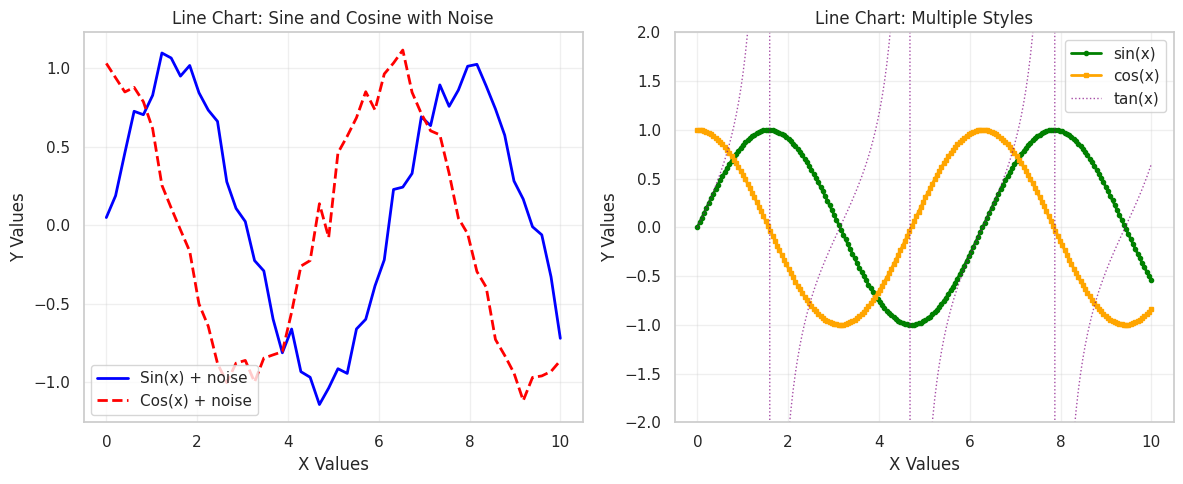


--- Line Chart Customization Options ---
Line styles: '-' solid, '--' dashed, '-.' dash-dot, ':' dotted
Markers: 'o' circle, 's' square, '^' triangle, '*' star, 'D' diamond
Colors: 'b' blue, 'r' red, 'g' green, 'k' black, or hex codes
Alpha: 0 (transparent) to 1 (opaque)


In [3]:
print("--- Line Chart Examples ---")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Example 1: Basic line chart (pyplot style)
axes[0].plot(x, y1, label='Sin(x) + noise', color='blue', linewidth=2)
axes[0].plot(x, y2, label='Cos(x) + noise', color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('X Values')
axes[0].set_ylabel('Y Values')
axes[0].set_title('Line Chart: Sine and Cosine with Noise')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Example 2: Multiple line styles
x_smooth = np.linspace(0, 10, 200)
y_sin = np.sin(x_smooth)
y_cos = np.cos(x_smooth)
y_tan = np.tan(x_smooth)

axes[1].plot(x_smooth, y_sin, label='sin(x)', color='green', linewidth=2, marker='o', markersize=3)
axes[1].plot(x_smooth, y_cos, label='cos(x)', color='orange', linewidth=2, marker='s', markersize=3)
axes[1].plot(x_smooth, y_tan, label='tan(x)', color='purple', linewidth=1, linestyle=':', alpha=0.7)
axes[1].set_xlabel('X Values')
axes[1].set_ylabel('Y Values')
axes[1].set_title('Line Chart: Multiple Styles')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-2, 2)  # Limit y-axis for better visualization

plt.tight_layout()
plt.show()

# Example with markers and formatting
print("\n--- Line Chart Customization Options ---")
print("Line styles: '-' solid, '--' dashed, '-.' dash-dot, ':' dotted")
print("Markers: 'o' circle, 's' square, '^' triangle, '*' star, 'D' diamond")
print("Colors: 'b' blue, 'r' red, 'g' green, 'k' black, or hex codes")
print("Alpha: 0 (transparent) to 1 (opaque)")

## 4. Bar Charts

**What is a Bar Chart?**
- Shows categorical data with rectangular bars
- The height/length represents the value
- Bars are separated to show distinct categories

**When to Use:**
✅ Comparing values across categories
✅ Showing ranking or order
✅ Visualizing counts or frequencies
✅ Displaying grouped or stacked data

**Types of Bar Charts:**
1. **Vertical**: Standard bar chart (most common)
2. **Horizontal**: Useful for long category names
3. **Grouped**: Compare sub-categories
4. **Stacked**: Show composition of each bar
5. **Percentage Stacked**: Show relative proportions

--- Bar Chart Examples ---


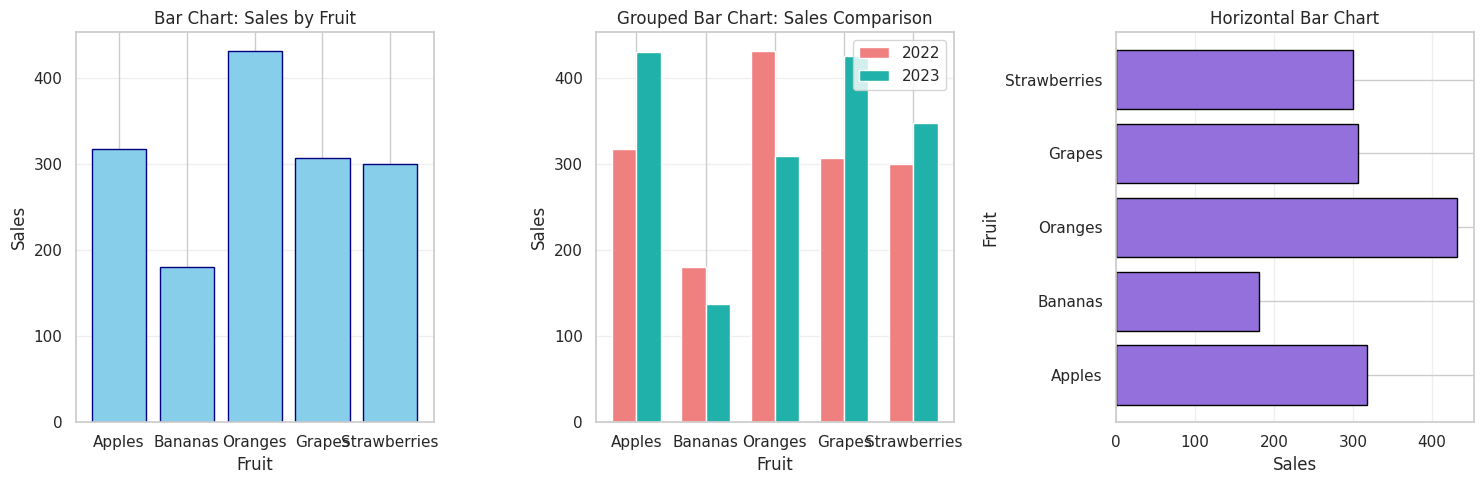


--- Bar Chart Customization Options ---
Colors: Use color parameter for solid colors
Edgecolor: Border of bars
Alpha: Transparency of bars
Width: Thickness of bars (0.1 to 1.0)
Orientation: bar() for vertical, barh() for horizontal


In [4]:
print("--- Bar Chart Examples ---")

# Create data for bar charts
categories = ['Apples', 'Bananas', 'Oranges', 'Grapes', 'Strawberries']
sales_2022 = np.random.randint(100, 500, 5)
sales_2023 = np.random.randint(100, 500, 5)

# Figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Example 1: Basic bar chart
axes[0].bar(categories, sales_2022, color='skyblue', edgecolor='navy', linewidth=1)
axes[0].set_xlabel('Fruit')
axes[0].set_ylabel('Sales')
axes[0].set_title('Bar Chart: Sales by Fruit')
axes[0].grid(True, alpha=0.3, axis='y')

# Example 2: Grouped bar chart
x = np.arange(len(categories))
width = 0.35

bars1 = axes[1].bar(x - width/2, sales_2022, width, label='2022', color='lightcoral')
bars2 = axes[1].bar(x + width/2, sales_2023, width, label='2023', color='lightseagreen')
axes[1].set_xlabel('Fruit')
axes[1].set_ylabel('Sales')
axes[1].set_title('Grouped Bar Chart: Sales Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Example 3: Horizontal bar chart
axes[2].barh(categories, sales_2022, color='mediumpurple', edgecolor='black')
axes[2].set_xlabel('Sales')
axes[2].set_ylabel('Fruit')
axes[2].set_title('Horizontal Bar Chart')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n--- Bar Chart Customization Options ---")
print("Colors: Use color parameter for solid colors")
print("Edgecolor: Border of bars")
print("Alpha: Transparency of bars")
print("Width: Thickness of bars (0.1 to 1.0)")
print("Orientation: bar() for vertical, barh() for horizontal")

## 5. Scatter Plots

**What is a Scatter Plot?**
- Shows the relationship between two variables
- Points represent individual data points
- Position on X and Y axes shows values

**When to Use:**
✅ Showing correlation between two variables
✅ Identifying clusters or patterns
✅ Detecting outliers
✅ Visualizing relationships in data

**Key Concepts:**
- **Positive Correlation**: X increases, Y increases
- **Negative Correlation**: X increases, Y decreases
- **No Correlation**: No clear pattern
- **Outliers**: Points far from the main cluster
- **Clusters**: Groups of points

--- Scatter Plot Examples ---


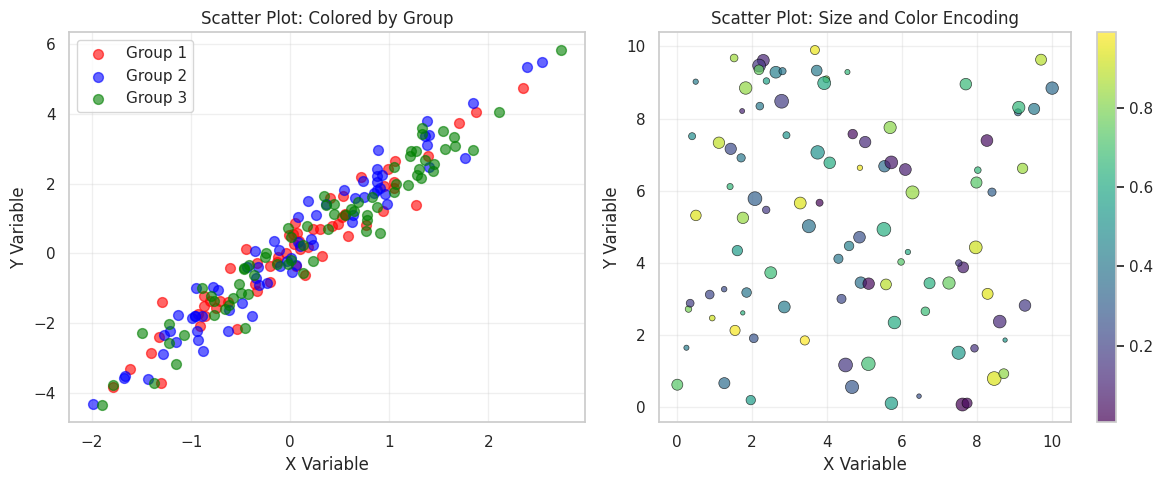


--- Scatter Plot Customization Options ---
Size (s): Point size in pixels
Color (c): Single color or array of colors
Alpha: Transparency (0.0 to 1.0)
Marker: 'o' circle, '^' triangle, 's' square, '*' star
Edgecolors: Border color of points
Colormap: 'viridis', 'plasma', 'coolwarm', 'rainbow', etc.


In [5]:
print("--- Scatter Plot Examples ---")

# Figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Example 1: Basic scatter plot with different groups
colors = {'Group 1': 'red', 'Group 2': 'blue', 'Group 3': 'green'}
for group in np.unique(groups):
    mask = groups == group
    axes[0].scatter(x_scatter[mask], y_scatter[mask],
                   label=group, color=colors[group], alpha=0.6, s=50)

axes[0].set_xlabel('X Variable')
axes[0].set_ylabel('Y Variable')
axes[0].set_title('Scatter Plot: Colored by Group')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Example 2: Scatter plot with size and color variation
x_range = np.random.rand(100) * 10
y_range = np.random.rand(100) * 10
sizes = np.random.randint(10, 100, 100)
colors_range = np.random.rand(100)

scatter = axes[1].scatter(x_range, y_range, s=sizes, c=colors_range,
                         alpha=0.7, cmap='viridis', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('X Variable')
axes[1].set_ylabel('Y Variable')
axes[1].set_title('Scatter Plot: Size and Color Encoding')
plt.colorbar(scatter, ax=axes[1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Scatter Plot Customization Options ---")
print("Size (s): Point size in pixels")
print("Color (c): Single color or array of colors")
print("Alpha: Transparency (0.0 to 1.0)")
print("Marker: 'o' circle, '^' triangle, 's' square, '*' star")
print("Edgecolors: Border color of points")
print("Colormap: 'viridis', 'plasma', 'coolwarm', 'rainbow', etc.")

## 6. Histograms

**What is a Histogram?**
- Shows the distribution of a single numerical variable
- Data is divided into bins (intervals)
- Height of bars shows frequency or density

**When to Use:**
✅ Understanding the distribution of data
✅ Identifying skewness or symmetry
✅ Detecting multimodal distributions
✅ Seeing where data is concentrated

**Key Concepts:**
- **Bins**: Number of intervals (too few loses detail, too many shows noise)
- **Density vs Count**: Probability density vs frequency
- **Skewness**: Asymmetric distribution
- **Kurtosis**: Tailedness of distribution
- **Modality**: Number of peaks (unimodal, bimodal, multimodal)

**Common Distributions:**
- **Normal (Bell Curve)**: Symmetric, mean = median = mode
- **Uniform**: Equal frequency across all values
- **Skewed (Right/Left)**: Tail on one side
- **Bimodal**: Two peaks

--- Histogram Examples ---


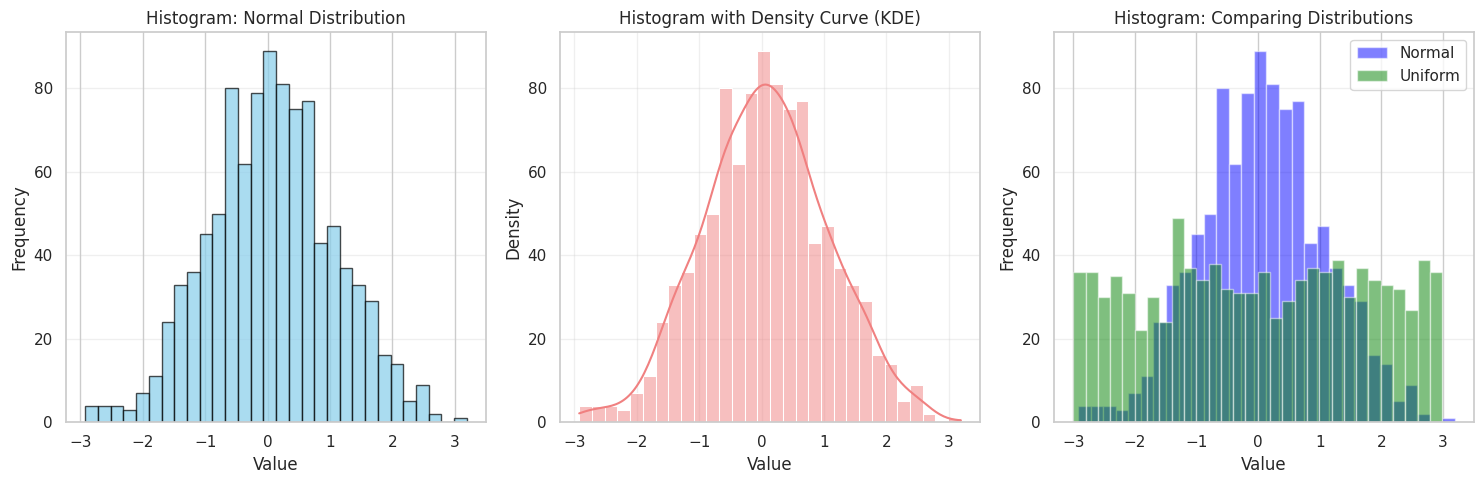


--- Histogram Customization Options ---
Bins: Number of intervals (10-50 usually works well)
Alpha: Transparency for overlapping histograms
Density: True for probability density, False for counts
Cumulative: True for cumulative distribution
Range: (min, max) to focus on specific region

For Seaborn histplot:
kde=True: Adds smooth density curve
hue: Color by categorical variable
multiple='layer': Overlay, 'stack': Stack, 'dodge': Separate


In [6]:
print("--- Histogram Examples ---")

# Figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Example 1: Basic histogram
axes[0].hist(data_normal, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram: Normal Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

# Example 2: Histogram with density curve (using Seaborn)
sns.histplot(data_normal, bins=30, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].set_title('Histogram with Density Curve (KDE)')
axes[1].grid(True, alpha=0.3)

# Example 3: Multiple histograms comparison
axes[2].hist(data_normal, bins=30, alpha=0.5, label='Normal', color='blue')
axes[2].hist(data_uniform, bins=30, alpha=0.5, label='Uniform', color='green')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Histogram: Comparing Distributions')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n--- Histogram Customization Options ---")
print("Bins: Number of intervals (10-50 usually works well)")
print("Alpha: Transparency for overlapping histograms")
print("Density: True for probability density, False for counts")
print("Cumulative: True for cumulative distribution")
print("Range: (min, max) to focus on specific region")
print("\nFor Seaborn histplot:")
print("kde=True: Adds smooth density curve")
print("hue: Color by categorical variable")
print("multiple='layer': Overlay, 'stack': Stack, 'dodge': Separate")

## 7. Correlation Heatmaps

**What is a Correlation Heatmap?**
- Visualizes the correlation matrix of variables
- Colors show strength and direction of relationships
- Essential for understanding multivariate data

**When to Use:**
✅ Exploring relationships between multiple variables
✅ Identifying highly correlated features (for feature selection)
✅ Understanding the structure of your data
✅ Communicating correlation patterns

**Correlation Values:**
- **+1.0**: Perfect positive correlation
- **+0.5 to +0.7**: Strong positive correlation
- **+0.3 to +0.5**: Moderate positive correlation
- **+0.0 to +0.3**: Weak positive correlation
- **0.0**: No correlation
- **-0.3 to 0.0**: Weak negative correlation
- **-0.5 to -0.3**: Moderate negative correlation
- **-0.7 to -0.5**: Strong negative correlation
- **-1.0**: Perfect negative correlation

--- Correlation Heatmap Examples ---
Correlation Matrix:
            Feature_A  Feature_B  Feature_C  Feature_D
Feature_A   1.000000   0.603240  -0.464442  -0.024526
Feature_B   0.603240   1.000000  -0.343830  -0.111982
Feature_C  -0.464442  -0.343830   1.000000   0.159957
Feature_D  -0.024526  -0.111982   0.159957   1.000000


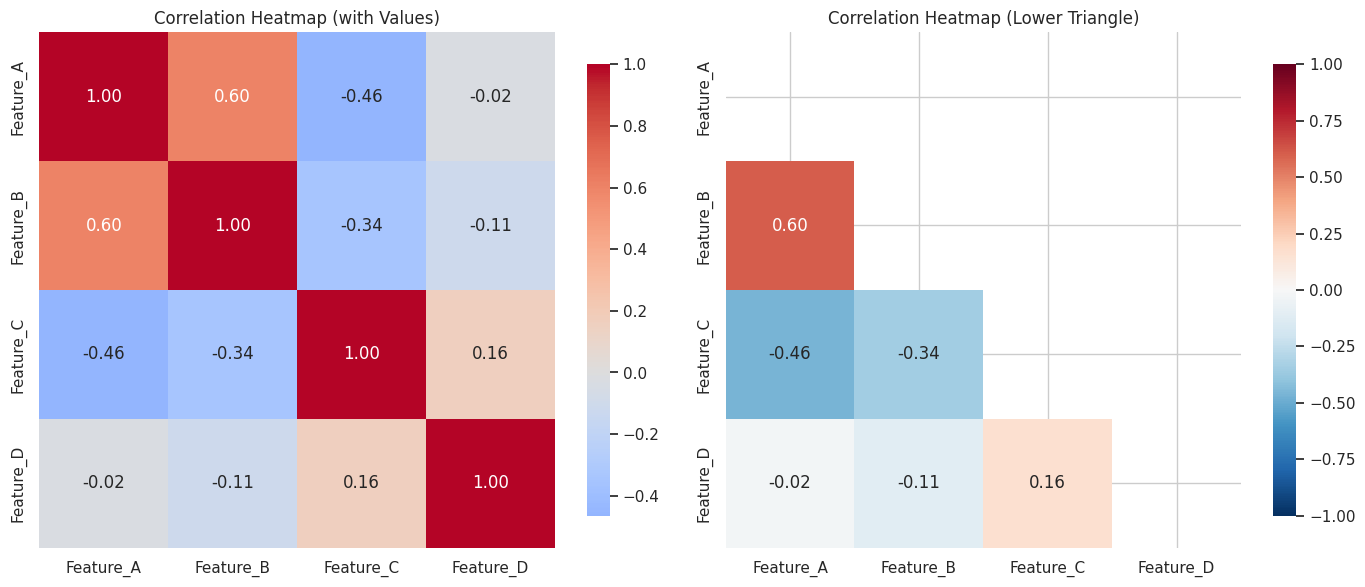


--- Heatmap Customization Options ---
annot=True: Display correlation values
fmt: Format for annotations ('.2f' for 2 decimals)
cmap: Colormap ('coolwarm', 'RdBu_r', 'viridis', etc.)
vmin/vmax: Set color scale range
square=True: Make cells square
mask: Hide upper or lower triangle
linewidths: Add borders between cells
cbar_kws: Customize color bar


In [7]:
print("--- Correlation Heatmap Examples ---")

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()
print("Correlation Matrix:\n", correlation_matrix)

# Create figure with two heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Example 1: Basic heatmap (Seaborn)
sns.heatmap(correlation_matrix,
            annot=True,           # Show values in cells
            fmt='.2f',            # Format values to 2 decimals
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap (with Values)')

# Example 2: Customized heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(correlation_matrix,
            mask=mask,            # Hide upper triangle
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            vmin=-1, vmax=1,      # Fixed color range
            square=True,
            ax=axes[1],
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12})
axes[1].set_title('Correlation Heatmap (Lower Triangle)')

plt.tight_layout()
plt.show()

print("\n--- Heatmap Customization Options ---")
print("annot=True: Display correlation values")
print("fmt: Format for annotations ('.2f' for 2 decimals)")
print("cmap: Colormap ('coolwarm', 'RdBu_r', 'viridis', etc.)")
print("vmin/vmax: Set color scale range")
print("square=True: Make cells square")
print("mask: Hide upper or lower triangle")
print("linewidths: Add borders between cells")
print("cbar_kws: Customize color bar")

## 8. Visualization Best Practices

### 1. **Choose the Right Chart Type**

| Goal | Best Chart |
|------|-----------|
| Show trends over time | Line chart |
| Compare categories | Bar chart |
| Show relationships | Scatter plot |
| Show distribution | Histogram, Box plot |
| Show correlations | Heatmap |
| Show proportions | Pie chart (limited use) |

### 2. **Color Guidelines**

**Do's:**
✅ Use colorblind-friendly palettes
✅ Use consistent colors across multiple plots
✅ Use intuitive colors (red = negative, green = positive)
✅ Use sequential colormaps for ordered data
✅ Use diverging colormaps for data with a meaningful midpoint

**Don'ts:**
❌ Use too many colors (max 5-7)
❌ Use red-green combinations (colorblind issues)
❌ Use rainbow colormaps
❌ Use color when grayscale would work

### 3. **Axis and Labels**

**Always:**
- Label x and y axes clearly
- Include units if applicable
- Use appropriate font sizes
- Add a descriptive title
- Use consistent formatting

**Avoid:**
- Unlabeled axes
- Overlapping labels
- Too much text
- Missing legends

### 4. **Data-to-Ink Ratio**

**High Data-to-Ink Ratio:**
- Remove unnecessary grid lines
- Remove 3D effects
- Remove shadows and gradients
- Keep it simple

### 5. **Accessibility**

**Consider:**
- Colorblind-friendly palettes
- Readable font sizes
- High contrast
- Patterns/shapes in addition to colors

### 6. **Consistency**

**Maintain:**
- Same color scheme across plots
- Same axis scales for comparisons
- Same font family
- Same style throughout

### 7. **Common Mistakes to Avoid**

1. **Misleading axis ranges**: Start y-axis at 0 unless there's a good reason
2. **Too much information**: Cluttered charts are hard to read
3. **Inappropriate chart type**: Don't use pie charts for many categories
4. **Missing context**: Always explain what the chart shows
5. **Over-decoration**: Avoid unnecessary 3D effects, animations, etc.

In [ ]:
print("--- Best Practices Demonstration ---")

# Create a figure comparing good vs bad practices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bad practice example
x = np.linspace(0, 10, 20)
y = x * 2 + np.random.randn(20) * 2

axes[0].scatter(x, y, color='red')
axes[0].set_title('Bad Plot', fontsize=14)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(False)  # No grid
axes[0].set_xticks([])  # No tick labels
axes[0].set_yticks([])  # No tick labels
# No legend
# No proper formatting

# Good practice example
axes[1].scatter(x, y,
               color='steelblue',
               alpha=0.7,
               edgecolors='white',
               s=80,
               label='Data points')

# Add trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[1].plot(x, p(x),
            color='darkred',
            linestyle='--',
            linewidth=2,
            label='Trend line')

axes[1].set_title('Good Plot Example', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X Values (units)', fontsize=12)
axes[1].set_ylabel('Y Values (units)', fontsize=12)
axes[1].legend(loc='upper left', frameon=True, framealpha=0.9)
axes[1].grid(True, alpha=0.3, linestyle='-')
axes[1].set_xticks(np.arange(0, 11, 2))
axes[1].set_yticks(np.arange(0, 25, 5))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n--- Bad vs Good Practices ---")
print("Bad plot: No grid, no labels, no legend, messy")
print("Good plot: Clean grid, clear labels, legend, formatted")
print("\nKey improvements in good plot:")
print("✓ Clear title and axis labels")
print("✓ Grid for readability (subtle)")
print("✓ Legend explains elements")
print("✓ Appropriate tick marks")
print("✓ Consistent color scheme")

## 9. Real-World Example: EDA with Visualization

**Scenario:** Analyzing a sales dataset to understand patterns and make decisions

In [ ]:
print("--- Real-World Example: Sales Data Analysis ---")

# Create realistic sales data
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')
n = len(dates)

sales_data = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(5000, 1000, n).round(2),
    'Customers': np.random.randint(50, 150, n),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Food'], n),
    'Revenue': np.random.normal(10000, 2000, n).round(2)
})

# Add some trends
trend = np.linspace(0, 2000, n)
sales_data['Sales'] = sales_data['Sales'] + trend
sales_data['Revenue'] = sales_data['Revenue'] + trend * 2

# Add seasonality
seasonal = 500 * np.sin(np.linspace(0, 4*np.pi, n))
sales_data['Sales'] = sales_data['Sales'] + seasonal

print("Sales Data (first 5 rows):\n", sales_data.head())

# Create a dashboard of visualizations
fig = plt.figure(figsize=(16, 12))

# 1. Time series of sales (Line chart)
ax1 = plt.subplot(3, 2, 1)
ax1.plot(sales_data['Date'], sales_data['Sales'], linewidth=1, color='steelblue', alpha=0.7)
ax1.set_title('Daily Sales Trend', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Sales by Product Category (Bar chart)
ax2 = plt.subplot(3, 2, 2)
category_sales = sales_data.groupby('Product_Category')['Sales'].mean()
bars = ax2.bar(category_sales.index, category_sales.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_title('Average Sales by Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Average Sales')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Sales vs Customers (Scatter plot)
ax3 = plt.subplot(3, 2, 3)
sample = sales_data.sample(500)
ax3.scatter(sample['Customers'], sample['Sales'],
           alpha=0.5, c=sample['Revenue'], cmap='viridis', s=30)
ax3.set_title('Sales vs Customers', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Customers')
ax3.set_ylabel('Sales')
plt.colorbar(ax3.collections[0], ax=ax3, label='Revenue')
ax3.grid(True, alpha=0.3)

# 4. Sales Distribution (Histogram)
ax4 = plt.subplot(3, 2, 4)
ax4.hist(sales_data['Sales'], bins=30, color='mediumpurple',
        edgecolor='black', alpha=0.7)
ax4.set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sales')
ax4.set_ylabel('Frequency')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Monthly Sales (Box plot)
ax5 = plt.subplot(3, 2, 5)
sales_data['Month'] = sales_data['Date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.boxplot(x='Month', y='Sales', data=sales_data, order=month_order, ax=ax5)
ax5.set_title('Monthly Sales Distribution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Month')
ax5.set_ylabel('Sales')
ax5.tick_params(axis='x', rotation=45)

# 6. Category by Weekday (Heatmap-like)
ax6 = plt.subplot(3, 2, 6)
sales_data['Weekday'] = sales_data['Date'].dt.day_name()
pivot = pd.pivot_table(sales_data,
                      values='Sales',
                      index='Product_Category',
                      columns='Weekday',
                      aggfunc='mean')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[weekday_order]
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Sales'})
ax6.set_title('Sales by Category and Weekday', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- Key Insights from Visualization Dashboard ---")
print("1. Sales trend shows upward pattern with seasonal variations")
print("2. Electronics category has highest average sales")
print("3. Strong positive correlation between customers and sales")
print("4. Sales distribution is roughly normal with slight skew")
print("5. Sales vary significantly by month and weekday")

## Summary: Key Concepts to Remember

### 1. **Matplotlib (Low-level, Full Control)**
```python
fig, ax = plt.subplots()     # Create figure and axes
ax.plot(x, y)                # Plot data
ax.set_xlabel('X Label')     # Label axes
ax.set_title('Title')        # Add title
ax.legend()                  # Add legend
plt.show()                   # Display
```

### 2. **Seaborn (High-level, Statistical)**
```python
sns.set_theme()               # Set style
sns.lineplot(x='x', y='y', data=df)     # Line chart
sns.barplot(x='x', y='y', data=df)      # Bar chart
sns.scatterplot(x='x', y='y', data=df)  # Scatter plot
sns.histplot(data['col'])               # Histogram
sns.heatmap(correlation)                # Heatmap
```

### 3. **Choosing the Right Plot**

| Data Type | Best Visualization |
|-----------|-------------------|
| Time series | Line chart |
| Categorical comparison | Bar chart |
| Two continuous variables | Scatter plot |
| Single variable distribution | Histogram |
| Correlation matrix | Heatmap |
| Categorical distribution | Box plot |
| Proportions | Pie chart (limited) |

### 4. **Best Practices Checklist**

**✅ Always:**
- [ ] Label axes clearly (with units if applicable)
- [ ] Add descriptive title
- [ ] Include legend when needed
- [ ] Use appropriate colors
- [ ] Set proper axis scales
- [ ] Add grid (subtle)
- [ ] Make it readable

**❌ Avoid:**
- [ ] Misleading axis ranges
- [ ] Too much clutter
- [ ] Unnecessary 3D effects
- [ ] Overlapping labels
- [ ] Missing context
- [ ] Inconsistent colors

### 5. **Common Color Palettes**

**Matplotlib:**
- Sequential: 'viridis', 'plasma', 'inferno'
- Diverging: 'coolwarm', 'RdBu', 'RdYlBu'
- Qualitative: 'Set1', 'Set2', 'Set3', 'tab10'

**Seaborn:**
- 'deep', 'muted', 'bright', 'pastel', 'dark'
- 'colorblind' (best for accessibility)
- Built-in: sns.set_palette('viridis')

### 6. **Performance Tips**

- Use `plt.close()` to free memory
- For large datasets, sample data
- Use `plt.tight_layout()` to avoid overlapping
- Save figures with `plt.savefig('file.png', dpi=300)`

### 7. **Accessibility Guidelines**

1. **Colorblind-friendly palettes**
2. **Sufficient font sizes** (10-12pt minimum)
3. **High contrast** between elements
4. **Shapes** in addition to colors
5. **Clear labels** and legends

---
**Additional Resources:**
- Matplotlib Gallery: https://matplotlib.org/gallery/
- Seaborn Gallery: https://seaborn.pydata.org/examples/
- Color Brewer: https://colorbrewer2.org/
- Visualization Best Practices: https://www.data-to-viz.com/